Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 25.1.0 25B78)

CPU model: Apple M3 Max
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 8352 rows, 4309 columns and 80875 nonzeros
Model fingerprint: 0xa92c93f1
Model has 3624 simple general constraints
  3624 INDICATOR
Variable types: 3101 continuous, 1208 integer (1208 binary)
Coefficient statistics:
  Matrix range     [2e-01, 8e+03]
  Objective range  [2e+00, 4e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-02, 3e+03]
  GenCon rhs range [2e+01, 4e+03]
  GenCon coe range [1e+00, 5e+06]
Presolve added 983 rows and 2661 columns
Presolve time: 0.23s
Presolved: 9335 rows, 6970 columns, 67432 nonzeros
Presolved model has 3600 SOS constraint(s)
Variable types: 5762 continuous, 1208 integer (1208 binary)

Root relaxation: objective 5.254827e+01, 10159 iterations, 0.41 seconds (0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


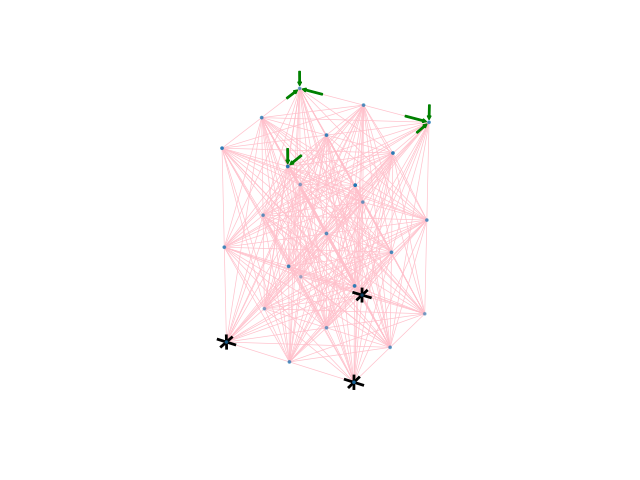

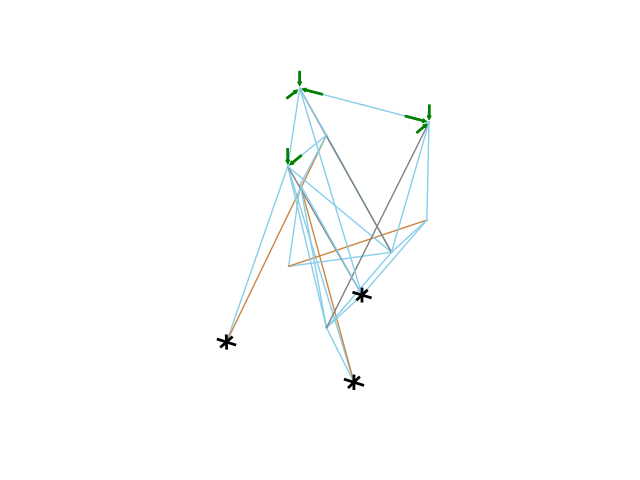

In [ ]:
import numpy as np
np.set_printoptions(threshold = np.inf)
from scipy import sparse
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
import mpl_toolkits.mplot3d as a3
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D
from math import gcd, ceil, floor
%matplotlib widget


# --------------------------------------------- Initial User Inputs ---------------------------------------------
x_dim = 1.5 # units: [meters]
nelx = 2
y_dim = 1.5 # units: [meters]
nely = 2
z_dim = 3 # units: [meters]
nelz = 2
yz_symm_on_x_max_plane = False

material_colors = ['skyblue','gray', 'peru'] # [steel cables, steel truss, timber truss]
C = np.array([1.45*78.5, 1.45*78.5, 0.49*5.5]) # units: kgCO2e/(meter*decimeter^2)
st = np.array([0.4*3450, 0, 0]) # units: kN/decimeter^2 (345 MPa/50 ksi, 9.653 MPa/1.40 ksi)
sc = np.array([0, 0.4*3450, 0.4*113.8]) # units: kN/decimeter^2 (345 MPa/50 ksi, 11.38 MPa/1.65 ksi)
E = np.array([2000000, 2000000, 131000]) # units: kN/decimeter^2 (200000 MPa/29000 ksi, 13100 MPa/1900 ksi)
a_min = np.array([0.01, 0.3, 0.3]) # units: decimeter^2
a_max = np.array([0.3, 2, 2]) # units: decimeter^2

max_node = 8
theta_min = 10 # units: degrees

conn = 'total' # conn is either 'local' or 'total'
no_intersect = True

tensegrity = True
prestress = True # Set true if tensegrity is True
if prestress == True:
    q0_t_min = 5 # units: kN
    q0_c_min = 5 # units: kN

plot_load_scale = 1/10
plot_bc_scale = 1/30


# ------------------------------------------- Generate Node Locations -------------------------------------------
# nodes[x,y,z] = nodal coordinate matrix where:
#                x = x-coordinate
#                y = y-coordinate
#                z = z-coordinate

nnx = nelx + 1
nny = nely + 1
nnz = nelz + 1
nnp = nnx*nny*nnz
max_node = max_node*np.ones(nnp)
nodes = np.zeros([nnp, 3])
count_z = 0
for i in range(nny*nnz):
    nodes[i*nnx:i*nnx+nnx, 0] = np.linspace(0 ,x_dim, nnx)
    nodes[i*nnx:i*nnx+nnx, 2] = count_z*z_dim/nelz
    count_z = count_z + 1
    if count_z == nnz:
        count_z = 0
if nely > 0:
    for i in range(nny):
        nodes[i*nnx*nnz:i*nnx*nnz+nnx*nnz, 1] = i*y_dim/nely

if yz_symm_on_x_max_plane == True:
    for i in range(nnp):
        if nodes[i,0] == max(nodes[:,0]):
            max_node[i] = np.floor(max_node[i]/2)


# ------------------------------------------- Set Boundary Conditions -------------------------------------------
# dof[i,N] = 1 if there is a degree of freedom in the direction N at node i = 0, ... , nnp-1
#          = 0 if there is a restraint in the direction N at node i = 0, ... , nnp-1

dof = np.ones((nnp, 3))

dof[0, :] = [0, 0, 0]
dof[nnx-1, :] = [0, 0, 0]
dof[int(nnp-nnx*nnz+nelx/2), :] = [0, 0, 0]

if yz_symm_on_x_max_plane == True:
    for i in range(nnp):
        if nodes[i,0] == max(nodes[:,0]):
            dof[i,:] = [0, 1, 1]

dof = dof.flatten()


# ------------------------------------------- Set Loading Conditions --------------------------------------------
# F[i,N] = P, where:
#          node i = 0, ... , nnp-1
#          N = 0,1,2 (direction of force)
#          P = magnitude of force

load_colors = ['green'] # Choose unique color for each load case
F1 = np.zeros((nnp, 3))

Fz = 75 # units: kN
Fx = 10 # units: kN
Fy = 10 # units: kN

# Define Exterior Loads Between Supports
F1[int(nnx*nnz-nelx/2-1), :] = [0, -Fy, -Fz]
F1[int(nnp-nnx), :] = [-Fx, Fy, -Fz]
# F1[int(nnx*nnz*(nely/2+1)-nelx/2-1), :] = [0, 0, -Fz]
F1[nnp-1, :] = [Fx, Fy, -Fz]

F1 = F1.flatten()

F = np.zeros((3*nnp, 1))
F[:,0] = F1


# ------------------------------------------ Construct Ground Structure -----------------------------------------
# ien[i,j] = ground structure matrix where:
#                i = 1st node of truss element
#                j = 2nd node of truss element

if conn == 'local':
    c_trav = 0
    index = 0
    x_trav = 0
    y_trav = 0
    z_trav = 0
    mem_count = nny*(nelx*nnz + nelz*nnx + 2*nelx*nelz) + nely*(nnx*nnz + 2*nelx*nnz + 2*nelz*nnx + 4*nelx*nelz)
    ien = np.zeros([mem_count, 2])
    while c_trav < nnp-1:
        if x_trav == 0:
            ien[index, :] = [c_trav, c_trav+1]
            index = index + 1
            if z_trav < nnz-1:
                ien[index, :] = [c_trav, c_trav+nnx]
                ien[index+1, :] = [c_trav, c_trav+nnx+1]
                index = index + 2
            if y_trav < nny-1:
                if z_trav > 0:
                    ien[index, :] = [c_trav, c_trav+nnx*nnz-nnx]
                    ien[index+1, :] = [c_trav, c_trav+nnx*nnz-nnx+1]
                    index = index + 2
                ien[index, :] = [c_trav, c_trav+nnx*nnz]
                ien[index+1, :] = [c_trav, c_trav+nnx*nnz+1]
                index = index + 2
                if z_trav < nnz-1:
                    ien[index, :] = [c_trav, c_trav+nnx*nnz+nnx]
                    ien[index+1, :] = [c_trav, c_trav+nnx*nnz+nnx+1]
                    index = index + 2
            x_trav = x_trav + 1
            c_trav = c_trav + 1
        elif x_trav == nnx-1:
            if z_trav < nnz-1:
                ien[index, :] = [c_trav, c_trav+nnx-1]
                ien[index+1, :] = [c_trav, c_trav+nnx]
                index = index + 2
            if y_trav < nny-1:
                if z_trav > 0:
                    ien[index, :] = [c_trav, c_trav+nnx*nnz-nnx-1]
                    ien[index+1, :] = [c_trav, c_trav+nnx*nnz-nnx]
                    index = index + 2
                ien[index, :] = [c_trav, c_trav+nnx*nnz-1]
                ien[index+1, :] = [c_trav, c_trav+nnx*nnz]
                index = index + 2
                if z_trav < nnz-1:
                    ien[index, :] = [c_trav, c_trav+nnx*nnz+nnx-1]
                    ien[index+1, :] = [c_trav, c_trav+nnx*nnz+nnx]
                    index = index + 2
            if z_trav == nnz-1:
                y_trav = y_trav + 1
                z_trav = 0
            else:
                z_trav = z_trav + 1
            x_trav = 0
            c_trav = c_trav + 1
        elif z_trav == nnz-1:
            ien[index, :] = [c_trav, c_trav+1]
            index = index + 1
            if y_trav < nny-1:
                ien[index, :] = [c_trav, c_trav+nnx*nnz-nnx-1]
                ien[index+1, :] = [c_trav, c_trav+nnx*nnz-nnx]
                ien[index+2, :] = [c_trav, c_trav+nnx*nnz-nnx+1]
                ien[index+3, :] = [c_trav, c_trav+nnx*nnz-1]
                ien[index+4, :] = [c_trav, c_trav+nnx*nnz]
                ien[index+5, :] = [c_trav, c_trav+nnx*nnz+1]
                index = index + 6
            x_trav = x_trav + 1
            c_trav = c_trav + 1
        elif y_trav == nny-1:
            ien[index, :] = [c_trav, c_trav+1]
            ien[index+1, :] = [c_trav, c_trav+nnx-1]
            ien[index+2, :] = [c_trav, c_trav+nnx]
            ien[index+3, :] = [c_trav, c_trav+nnx+1]
            index = index + 4
            x_trav = x_trav + 1
            c_trav = c_trav + 1
        else:
            ien[index, :] = [c_trav, c_trav+1]
            ien[index+1, :] = [c_trav, c_trav+nnx-1]
            ien[index+2, :] = [c_trav, c_trav+nnx]
            ien[index+3, :] = [c_trav, c_trav+nnx+1]
            index = index + 4
            if z_trav > 0:
                ien[index, :] = [c_trav, c_trav+nnx*nnz-nnx-1]
                ien[index+1, :] = [c_trav, c_trav+nnx*nnz-nnx]
                ien[index+2, :] = [c_trav, c_trav+nnx*nnz-nnx+1]
                index = index + 3
            ien[index, :] = [c_trav, c_trav+nnx*nnz-1]
            ien[index+1, :] = [c_trav, c_trav+nnx*nnz]
            ien[index+2, :] = [c_trav, c_trav+nnx*nnz+1]
            ien[index+3, :] = [c_trav, c_trav+nnx*nnz+nnx-1]
            ien[index+4, :] = [c_trav, c_trav+nnx*nnz+nnx]
            ien[index+5, :] = [c_trav, c_trav+nnx*nnz+nnx+1]
            index = index + 6
            x_trav = x_trav + 1
            c_trav = c_trav + 1
            
elif conn == 'total':
    ien_list = []
    for i in range(len(nodes)):
        node_add = i + 1
        angles = []
        while node_add < len(nodes):
            xyz = nodes[node_add, :] - nodes[i, :]
            if abs(xyz[0]) > 0:
                theta = np.arctan2(xyz[1], xyz[0])
            else:
                theta = 7
            phi = np.arccos(xyz[2] / (np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)))
            violation = 0
            for j in range(len(angles)):
                if np.allclose(angles[j], [theta, phi]):
                    violation = violation + 1
            if violation == 0:
                ien_list.append([i, node_add])
            angles.append([theta, phi])
            node_add = node_add + 1
    mem_count = len(ien_list)
    ien = np.zeros([mem_count, 2])
    for i in range(len(ien_list)):
        ien[i, :] = ien_list[i]


# ----------------------------------------- Define 3D Arrows for Plots -------------------------------------------

# Source: https://gist.github.com/WetHat/1d6cd0f7309535311a539b42cccca89c
class Arrow3D(FancyArrowPatch):
    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)
    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)
        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)
        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)
    
def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    '''Add an 3d arrow to an `Axes3D` instance.'''
    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)
setattr(Axes3D, 'arrow3D', _arrow3D)


# ------------------------------------------- Plot Ground Structure ---------------------------------------------

x_dim = max(nodes[:,0]) - min(nodes[:,0])
x_mid = np.average(np.array([max(nodes[:,0]), min(nodes[:,0])]))
y_dim = max(nodes[:,1]) - min(nodes[:,1])
y_mid = np.average(np.array([max(nodes[:,1]), min(nodes[:,1])]))
z_dim = max(nodes[:,2]) - min(nodes[:,2])
z_mid = np.average(np.array([max(nodes[:,2]), min(nodes[:,2])]))
dim = max(x_dim, y_dim, z_dim)

fig1 = plt.figure()
ax1 = fig1.add_subplot(111, projection = '3d')
ax1.plot([0, dim], [0, dim], [0, dim], color = 'w', linewidth = 0)
ax1.scatter(nodes[:,0], nodes[:,1], nodes[:,2], s = 3)
for i in range(len(ien)):
    node1 = ien[i, 0].astype(int)
    node2 = ien[i, 1].astype(int)
    x0 = [nodes[node1, 0], nodes[node2, 0]]
    y0 = [nodes[node1, 1], nodes[node2, 1]]
    z0 = [nodes[node1, 2], nodes[node2, 2]]
    ax1.plot(x0, y0, z0, color = 'pink', linewidth = 1/2)
ax1.view_init(elev = 30, azim = -60)
ax1.axes.set_xlim3d(left = x_dim/2 - dim/2, right = x_dim/2 + dim/2) 
ax1.axes.set_ylim3d(bottom = y_dim/2 - dim/2, top = y_dim/2 + dim/2) 
ax1.axes.set_zlim3d(bottom = 0, top = dim)
ax1.axis('off')
            
# Plot Boundary and Loading Conditions
index = 0
for i in range(len(dof)):
    if index == 0:
        index = 1
        if dof[i] == 0:
            ax1.plot([nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], \
                    [nodes.flatten()[i + 2], nodes.flatten()[i + 2]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax1.arrow3D(x = nodes.flatten()[i],
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax1.arrow3D(x = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    elif index == 1:
        index = 2
        if dof[i] == 0:
            ax1.plot([nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax1.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i],
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax1.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    else:
        index = 0
        if dof[i] == 0:
            ax1.plot([nodes.flatten()[i - 2], nodes.flatten()[i - 2]], \
                    [nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                        color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax1.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i],
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax1.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

            
# ---------------------------- Construct Element Length Vector and Equilibrium Matrix ---------------------------

l = np.zeros(mem_count)
for i in range(mem_count):
    node1 = ien[i, 0].astype(int)
    node2 = ien[i, 1].astype(int)
    x0 = [nodes[node1, 0], nodes[node2, 0]]
    y0 = [nodes[node1, 1], nodes[node2, 1]]
    z0 = [nodes[node1, 2], nodes[node2, 2]]
    l[i] = np.sqrt((x0[1] - x0[0])**2 + (y0[1] - y0[0])**2 + (z0[1] - z0[0])**2)
nodes1 = ien[:, 0].astype(int)
nodes2 = ien[:, 1].astype(int)
dX = nodes[nodes2, 0] - nodes[nodes1, 0]
dY = nodes[nodes2, 1] - nodes[nodes1, 1]
dZ = nodes[nodes2, 2] - nodes[nodes1, 2]
d0 = dof[nodes1*3]
d1 = dof[nodes1*3+1]
d2 = dof[nodes1*3+2]
d3 = dof[nodes2*3]
d4 = dof[nodes2*3+1]
d5 = dof[nodes2*3+2]
s = np.concatenate((-dX/l*d0, -dY/l*d1, -dZ/l*d2, dX/l*d3, dY/l*d4, dZ/l*d5))
r = np.concatenate((nodes1*3, nodes1*3+1, nodes1*3+2, nodes2*3, nodes2*3+1, nodes2*3+2))
c = np.concatenate((np.arange(mem_count), np.arange(mem_count), np.arange(mem_count), \
                    np.arange(mem_count), np.arange(mem_count), np.arange(mem_count)))
Bcoo = sparse.coo_matrix((s, (r, c)), shape = (len(nodes)*3, mem_count))
B = Bcoo.tocsr()
Af = np.transpose(B)


# ---------------------------------------- Construct Element Node Matrix ----------------------------------------

n_data = []
n_i_row = []
n_j_col = []
for i in range(nnp):
    for j in range(mem_count):
        if ien[j, 0] == i:
            n_data.append(1)
            n_i_row.append(i)
            n_j_col.append(j)
        if ien[j, 1] == i:
            n_data.append(1)
            n_i_row.append(i)
            n_j_col.append(j)
n = sparse.coo_matrix((n_data, (n_i_row, n_j_col)), shape = (nnp, mem_count)).tocsr()


# -------------------------------------- Construct Projected Length Matrix --------------------------------------

l_proj_data = []
l_proj_k_row = []
l_proj_i_col = []
for k in range(len(F)):
    for i in range(mem_count):
        if ien[i, 0] == int(np.floor(k/3)) or ien[i, 1] == int(np.floor(k/3)):
            l_proj_k_row.append(k)
            l_proj_i_col.append(i)
            if np.mod(k,3) == 0:
                l_proj_data.append(np.sqrt((nodes[int(ien[i,0]), 1] - nodes[int(ien[i,1]), 1])**2 + \
                                           (nodes[int(ien[i,0]), 2] - nodes[int(ien[i,1]), 2])**2)/2)
            elif np.mod(k,3) == 1:
                l_proj_data.append(np.sqrt((nodes[int(ien[i,0]), 0] - nodes[int(ien[i,1]), 0])**2 + \
                                           (nodes[int(ien[i,0]), 2] - nodes[int(ien[i,1]), 2])**2)/2)
            elif np.mod(k,3) == 2:
                l_proj_data.append(np.sqrt((nodes[int(ien[i,0]), 0] - nodes[int(ien[i,1]), 0])**2 + \
                                           (nodes[int(ien[i,0]), 1] - nodes[int(ien[i,1]), 1])**2)/2)
l_proj = sparse.coo_matrix((l_proj_data, (l_proj_k_row, l_proj_i_col)), shape = (len(F), mem_count)).tocsr()


# ----------------------------------------- Construct Violation Matricies ---------------------------------------

V = np.zeros([mem_count, mem_count])
if tensegrity == True:
    V2 = np.zeros([mem_count, mem_count])
    Y = np.zeros([2, mem_count, mem_count])
    J = np.zeros([2, mem_count, mem_count])
for i in range(mem_count):
    for p in range(nnp):
        if n[p,i] == 1:
            for x in range(mem_count):
                if n[p,x] == 1:
                    if x != i:
                        i_node1 = ien[i,0].astype(int)
                        i_node2 = ien[i,1].astype(int)
                        x_node1 = ien[x,0].astype(int)
                        x_node2 = ien[x,1].astype(int)
                        a_edge = l[i]
                        b_edge = l[x]
                        if i_node1 == x_node1:
                            c_edge = np.sqrt((nodes[i_node2,0] - nodes[x_node2,0])**2 + \
                                             (nodes[i_node2,1] - nodes[x_node2,1])**2 + \
                                             (nodes[i_node2,2] - nodes[x_node2,2])**2)
                        elif i_node1 == x_node2:
                            c_edge = np.sqrt((nodes[i_node2,0] - nodes[x_node1,0])**2 + \
                                             (nodes[i_node2,1] - nodes[x_node1,1])**2 + \
                                             (nodes[i_node2,2] - nodes[x_node1,2])**2)
                        elif i_node2 == x_node1:
                            c_edge = np.sqrt((nodes[i_node1,0] - nodes[x_node2,0])**2 + \
                                             (nodes[i_node1,1] - nodes[x_node2,1])**2 + \
                                             (nodes[i_node1,2] - nodes[x_node2,2])**2)
                        elif i_node2 == x_node2:
                            c_edge = np.sqrt((nodes[i_node1,0] - nodes[x_node1,0])**2 + \
                                             (nodes[i_node1,1] - nodes[x_node1,1])**2 + \
                                             (nodes[i_node1,2] - nodes[x_node1,2])**2)
                        theta = abs(np.degrees(np.arccos((a_edge**2 + b_edge**2 - c_edge**2) / \
                                                         (2*a_edge*b_edge))))
                        if theta <= theta_min:
                            V[x,i] = 1
                        if tensegrity == True:
                            if abs(theta) >= 0.01 and abs(180-theta) >= 0.01:
                                V2[x,i] = 1

if no_intersect == True:
    for i in range(mem_count):
        for x in range(mem_count):
            if V[x,i] < 1/2 and x != i:
                i_node1 = ien[i,0].astype(int)
                i_node2 = ien[i,1].astype(int)
                x_node1 = ien[x,0].astype(int)
                x_node2 = ien[x,1].astype(int)
                vec1 = np.array([nodes[i_node2,0] - nodes[i_node1,0],
                                 nodes[i_node2,1] - nodes[i_node1,1],
                                 nodes[i_node2,2] - nodes[i_node1,2]])
                vec2 = np.array([nodes[x_node2,0] - nodes[x_node1,0],
                                 nodes[x_node2,1] - nodes[x_node1,1],
                                 nodes[x_node2,2] - nodes[x_node1,2]])

                # Check if line segments are parallel
                if np.allclose(np.cross(vec1, vec2), [0,0,0]):
                    # Check if line segments lie on the same line
                    vec_mix = np.array([nodes[x_node1,0] - nodes[i_node1,0],
                                        nodes[x_node1,1] - nodes[i_node1,1],
                                        nodes[x_node1,2] - nodes[i_node1,2]])
                    if np.allclose(np.cross(vec1, vec_mix), [0,0,0]):
                        # Check if line segments overlap
                        vec_direction = vec1/np.linalg.norm(vec1)
                        vec_i_node1_adjust = np.array([nodes[i_node1,0] + 0.01*vec1[0],
                                                    nodes[i_node1,1] + 0.01*vec1[1],
                                                    nodes[i_node1,2] + 0.01*vec1[2]])
                        vec_i_node2_adjust = np.array([nodes[i_node2,0] - 0.01*vec1[0],
                                                    nodes[i_node2,1] - 0.01*vec1[1],
                                                    nodes[i_node2,2] - 0.01*vec1[2]])
                        vec_x_node1_adjust = np.array([nodes[x_node1,0] + 0.01*vec2[0],
                                                    nodes[x_node1,1] + 0.01*vec2[1],
                                                    nodes[x_node1,2] + 0.01*vec2[2]])
                        vec_x_node2_adjust = np.array([nodes[x_node2,0] - 0.01*vec2[0],
                                                    nodes[x_node2,1] - 0.01*vec2[1],
                                                    nodes[x_node2,2] - 0.01*vec2[2]])
                        vec_i_node1_project = np.dot(vec_i_node1_adjust, vec_direction)
                        vec_i_node2_project = np.dot(vec_i_node2_adjust, vec_direction)
                        vec_x_node1_project = np.dot(vec_x_node1_adjust, vec_direction)
                        vec_x_node2_project = np.dot(vec_x_node2_adjust, vec_direction)
                        if max(vec_i_node1_project, vec_i_node2_project) >= \
                            min(vec_x_node1_project, vec_x_node2_project) \
                        and min(vec_i_node1_project, vec_i_node2_project) <= \
                            max(vec_x_node1_project, vec_x_node2_project):
                            V[x,i] = 1

                elif not np.allclose(np.linalg.det(np.array([[vec1[0], -vec2[0]], [vec1[1], -vec2[1]]])), 0):
                    A_matrix = np.array([[vec1[0], -vec2[0]],
                                         [vec1[1], -vec2[1]]])
                    b_vector = np.array([[nodes[x_node1,0] - nodes[i_node1,0]],
                                         [nodes[x_node1,1] - nodes[i_node1,1]]])
                    x_sol = np.linalg.solve(A_matrix, b_vector)
                    # Check if solution satisfies 3rd equation and falls within the bounds of each line segment
                    if np.allclose(nodes[i_node1,2] + vec1[2]*x_sol[0], nodes[x_node1,2] + vec2[2]*x_sol[1]) \
                    and 0.01 <= x_sol[0] <= 0.99 and 0.01 <= x_sol[1] <= 0.99:
                        V[x,i] = 1

                elif not np.allclose(np.linalg.det(np.array([[vec1[0], -vec2[0]], [vec1[2], -vec2[2]]])), 0):
                    A_matrix = np.array([[vec1[0], -vec2[0]],
                                         [vec1[2], -vec2[2]]])
                    b_vector = np.array([[nodes[x_node1,0] - nodes[i_node1,0]],
                                         [nodes[x_node1,2] - nodes[i_node1,2]]])
                    x_sol = np.linalg.solve(A_matrix, b_vector)
                    # Check if solution satisfies 3rd equation and falls within the bounds of each line segment
                    if np.allclose(nodes[i_node1,1] + vec1[1]*x_sol[0], nodes[x_node1,1] + vec2[1]*x_sol[1]) \
                    and 0.01 <= x_sol[0] <= 0.99 and 0.01 <= x_sol[1] <= 0.99:
                        V[x,i] = 1

                elif not np.allclose(np.linalg.det(np.array([[vec1[1], -vec2[1]], [vec1[2], -vec2[2]]])), 0):
                    A_matrix = np.array([[vec1[1], -vec2[1]],
                                         [vec1[2], -vec2[2]]])
                    b_vector = np.array([[nodes[x_node1,1] - nodes[i_node1,1]],
                                         [nodes[x_node1,2] - nodes[i_node1,2]]])
                    x_sol = np.linalg.solve(A_matrix, b_vector)
                    # Check if solution satisfies 3rd equation and falls within the bounds of each line segment
                    if np.allclose(nodes[i_node1,0] + vec1[0]*x_sol[0], nodes[x_node1,0] + vec2[0]*x_sol[1]) \
                    and 0.01 <= x_sol[0] <= 0.99 and 0.01 <= x_sol[1] <= 0.99:
                        V[x,i] = 1

if tensegrity == True:
    for x in range(mem_count):
        g = 0
        p = 0
        while g < 2:
            if n[p,x] == 1:
                for i in range(mem_count):
                    if n[p,i] == 1 and i != x:
                        i_node1 = ien[i,0].astype(int)
                        i_node2 = ien[i,1].astype(int)
                        x_node1 = ien[x,0].astype(int)
                        x_node2 = ien[x,1].astype(int)
                        
                        a_edge = l[i]
                        b_edge = l[x]
                        if i_node1 == x_node1:
                            c_edge = np.sqrt((nodes[i_node2,0] - nodes[x_node2,0])**2 + \
                                             (nodes[i_node2,1] - nodes[x_node2,1])**2 + \
                                             (nodes[i_node2,2] - nodes[x_node2,2])**2)
                        elif i_node1 == x_node2:
                            c_edge = np.sqrt((nodes[i_node2,0] - nodes[x_node1,0])**2 + \
                                             (nodes[i_node2,1] - nodes[x_node1,1])**2 + \
                                             (nodes[i_node2,2] - nodes[x_node1,2])**2)
                        elif i_node2 == x_node1:
                            c_edge = np.sqrt((nodes[i_node1,0] - nodes[x_node2,0])**2 + \
                                             (nodes[i_node1,1] - nodes[x_node2,1])**2 + \
                                             (nodes[i_node1,2] - nodes[x_node2,2])**2)
                        elif i_node2 == x_node2:
                            c_edge = np.sqrt((nodes[i_node1,0] - nodes[x_node1,0])**2 + \
                                             (nodes[i_node1,1] - nodes[x_node1,1])**2 + \
                                             (nodes[i_node1,2] - nodes[x_node1,2])**2)
                        theta = abs(np.degrees(np.arccos((a_edge**2 + b_edge**2 - c_edge**2) / \
                                                         (2*a_edge*b_edge))))
                        if abs(theta) >= 0.01 and abs(180-theta) >= 0.01:
                            J[g,x,i] = 1
                        else:
                            Y[g,x,i] = 1
                g = g + 1
            p = p + 1

for x in range(mem_count):
    V[x,x] = sum(V[x,:])
    if tensegrity == True:
        V2[x,x] = sum(V2[x,:])
        for g in range(np.shape(J)[0]):
            Y[g,x,:] = sum(J[g,x,:]) * Y[g,x,:]
            Y[g,x,x] = sum(J[g,x,:])

if yz_symm_on_x_max_plane == True:
    for i in range(mem_count):
        theta = 400
        i_node1 = ien[i,0].astype(int)
        i_node2 = ien[i,1].astype(int)
        a_edge = l[i]
        b_edge = 0
        c_edge = 0
        if nodes[i_node1,0] == max(nodes[:,0]):
            sym_node1 = nodes[i_node1,:]
            sym_node2 = np.array([max(nodes[:,0]), nodes[i_node2,1], nodes[i_node2,2]])
            b_edge = np.linalg.norm(sym_node2 - sym_node1)
            c_edge = np.sqrt((nodes[i_node2,0] - sym_node2[0])**2 + \
                             (nodes[i_node2,1] - sym_node2[1])**2 + \
                             (nodes[i_node2,2] - sym_node2[2])**2)
        elif nodes[i_node2,0] == max(nodes[:,0]):
            sym_node1 = nodes[i_node2,:]
            sym_node2 = np.array([max(nodes[:,0]), nodes[i_node1,1], nodes[i_node1,2]])
            b_edge = np.linalg.norm(sym_node2 - sym_node1)
            c_edge = np.sqrt((nodes[i_node1,0] - sym_node2[0])**2 + \
                             (nodes[i_node1,1] - sym_node2[1])**2 + \
                             (nodes[i_node1,2] - sym_node2[2])**2)
            
        if b_edge > 0 and c_edge > 0:
            theta = abs(np.degrees(np.arccos((a_edge**2 + b_edge**2 - c_edge**2) / \
                                             (2*a_edge*b_edge))))
        if theta <= theta_min/2:
            V[i,i] = 1

# Define Area Bounds Matrix
a_min_mat = np.zeros((mem_count, len(C)))
a_max_mat = np.zeros((mem_count, len(C)))
for i in range(mem_count):
    for j in range(len(C)):
        a_min_mat[i,j] = a_min[j]
        a_max_mat[i,j] = a_max[j]

a_min = a_min_mat
a_max = a_max_mat

# Define Maximum Elastic Strain Bounds
v_min = np.zeros((mem_count, len(C)))
v_max = np.zeros((mem_count, len(C)))
for i in range(mem_count):
    for j in range(len(C)):
        # v_min[i,j] = (-sc[j]*l[i] / E[j])
        # v_max[i,j] = (st[j]*l[i] / E[j])
        v_min[i,j] = -0.001*l[i]
        v_max[i,j] = 0.001*l[i]


# -------------------------------------------- Construct GUROBI Model -------------------------------------------

m = gp.Model()

N = mem_count
M = len(C)
N_F = len(F)
L_C = np.shape(F)[1]
N_np = nnp
amax_max = max(max(x) for x in a_max)
st_max = max(st)
sc_max = max(sc)
S_free = np.nonzero(dof)[0]
S_restrain = np.where(dof == 0)[0]
eps = 10**(-6)

# Define Variables
A = m.addMVar(shape = (N,M), lb = 0, vtype = GRB.CONTINUOUS, name = 'A')
a = m.addMVar(shape = (N,M), vtype = GRB.CONTINUOUS, name = 'a')
q = m.addMVar(shape = (N,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'q')
u = m.addMVar(shape = (N_F,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'u')
v = m.addMVar(shape = (N,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'v')
z = m.addMVar(shape = (N,M), vtype = GRB.BINARY, name = 'z')
if prestress == True:
    q0 = m.addMVar(shape = N, lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'q0')
    qe = m.addMVar(shape = (N,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'qe')
    z2 = m.addMVar(shape = N, lb = -1*float('inf'), vtype = GRB.BINARY, name = 'z2')

# Define Objective
m.setObjective(sum(l[i]*A[i,j]*C[j] for i in range(N) for j in range(M)), GRB.MINIMIZE)

# Define Constraints
m.addConstrs((sum(B[k,i]*q[i,h] for i in range(N)) == F[k,h] \
              for k in range(N_F) for h in range(L_C)), name = 'equilibrium')
m.addConstrs((sum(Af[i,k]*u[k,h] for k in range(N_F)) == v[i,h] \
              for i in range(N) for h in range(L_C)), name = 'compatibility')
if prestress == False:
    for i in range(N):
        for j in range(M):
            for h in range(L_C):
                m.addGenConstrIndicator(z[i,j], True, q[i,h] <= \
                                        E[j]/l[i] * (a_max[i,j]*v[i,h] + v_min[i,j]*A[i,j] - a_max[i,j]*v_min[i,j]), \
                                            name = 'McCormick_Over1')
                m.addGenConstrIndicator(z[i,j], True, q[i,h] <= \
                                        E[j]/l[i] * (a_min[i,j]*v[i,h] + v_max[i,j]*A[i,j] - a_min[i,j]*v_max[i,j]), \
                                            name = 'McCormick_Over2')
                m.addGenConstrIndicator(z[i,j], True, q[i,h] >= \
                                        E[j]/l[i] * (a_min[i,j]*v[i,h] + v_min[i,j]*A[i,j] - a_min[i,j]*v_min[i,j]), \
                                            name = 'McCormick_Under1')
                m.addGenConstrIndicator(z[i,j], True, q[i,h] >= \
                                        E[j]/l[i] * (a_max[i,j]*v[i,h] + v_max[i,j]*A[i,j] - a_max[i,j]*v_max[i,j]), \
                                            name = 'McCormick_Under2')

elif prestress == True:
    m.addConstrs((sum(B[k,i]*q0[i] for i in range(N)) == 0 for k in range(N_F)), name = 'equilibrium_prestress')
    m.addConstrs((q[i,h] == qe[i,h] + q0[i] for i in range(N) for h in range(L_C)), name = 'elongations_prestress')
    m.addConstrs((q0[i] >= (q0_t_min + sc_max*amax_max)*(sum(z[i,j] - z2[i] for j in range(M))) - sc_max*amax_max \
                  for i in range(N)), name = 'min_tension_prestress')
    m.addConstrs((q0[i] <= -q0_c_min*z2[i] + amax_max*st_max*(1 - z2[i]) \
                  for i in range(N)), name = 'min_compression_prestress')
    m.addConstrs((q0[i] <= sum(A[i,j]*st[j] for j in range(M)) for i in range(N)), name = 'tension_limit_prestress')
    m.addConstrs((q0[i] >= -sum(A[i,j]*sc[j] for j in range(M)) for i in range(N)), name = 'compress_limit_prestress')

    m.addConstrs((-sc_max*amax_max*z2[i] <= qe[i,h] for i in range(N) for h in range(L_C)), name = 'force_sign')
    m.addConstrs((qe[i,h] <= (st_max*amax_max + (st_max*amax_max*eps)/(1-eps))\
                  *(1-eps-z2[i]) for i in range(N) for h in range(L_C)), name = 'force_sign_2')
    
    for i in range(N):
        for j in range(M):
            for h in range(L_C):
                m.addGenConstrIndicator(z[i,j], True, qe[i,h] <= \
                                        E[j]/l[i] * (a_max[i,j]*v[i,h] + v_min[i,j]*A[i,j] - a_max[i,j]*v_min[i,j]), \
                                            name = 'McCormick_Over1')
                m.addGenConstrIndicator(z[i,j], True, qe[i,h] <= \
                                        E[j]/l[i] * (a_min[i,j]*v[i,h] + v_max[i,j]*A[i,j] - a_min[i,j]*v_max[i,j]), \
                                            name = 'McCormick_Over2')
                m.addGenConstrIndicator(z[i,j], True, qe[i,h] >= \
                                        E[j]/l[i] * (a_min[i,j]*v[i,h] + v_min[i,j]*A[i,j] - a_min[i,j]*v_min[i,j]), \
                                            name = 'McCormick_Under1')
                m.addGenConstrIndicator(z[i,j], True, qe[i,h] >= \
                                        E[j]/l[i] * (a_max[i,j]*v[i,h] + v_max[i,j]*A[i,j] - a_max[i,j]*v_max[i,j]), \
                                            name = 'McCormick_Under2')

m.addConstrs((q[i,h] <= sum(A[i,j]*st[j] for j in range(M)) \
              for i in range(N) for h in range(L_C)), name = 'tension_limit')
m.addConstrs((q[i,h] >= -sum(A[i,j]*sc[j] for j in range(M)) \
              for i in range(N) for h in range(L_C)), name = 'compress_limit')
m.addConstrs((sum(z[i,j] for j in range(M)) <= 1 for i in range(N)), name = 'unique_material')
m.addConstrs((sum(n[p,i]*z[i,j] for i in range(N) for j in range(M)) <= max_node[p] \
              for p in range(N_np)), name = 'max_node')
m.addConstrs((sum(V[x,i]*z[i,j] for i in range(N) for j in range(M)) <= V[x,x] for x in range(N)), name = 'min_angle')

if tensegrity == True:
    m.addConstrs((sum(V2[x,i]*z2[i] for i in range(N)) <= V2[x,x] for x in range(N)), name = 'tensegrity')
    m.addConstrs((sum(Y[g,x,i]*z2[i] for i in range(N)) + sum(J[g,x,i]*z[i,j] for i in range(N) for j in range(M)) \
                  <= 2*Y[g,x,x] for x in range(N) for g in range(2)))

m.addConstrs((A[i,j] <= a_max[i,j]*z[i,j] for i in range(N) for j in range(M)), name = 'max_Area')
m.addConstrs((A[i,j] >= a[i,j] - a_max[i,j]*(1 - z[i,j]) for i in range(N) for j in range(M)), name = 'big_M')
m.addConstrs((a[i,j] <= a_max[i,j] for i in range(N) for j in range(M)), name = 'max_area')
m.addConstrs((a[i,j] >= a_min[i,j] for i in range(N) for j in range(M)), name = 'min_area')
m.addConstrs((u[k,h] == 0 for k in S_restrain for h in range(L_C)))

m.optimize()

A_opt = A.X
a_opt = a.X
q_opt = q.X
u_opt = u.X
v_opt = v.X
z_opt = z.X
if prestress == True:
    q0_opt = q0.X
    qe_opt = qe.X
    z2_opt = z2.X
                            

# ------------------------------------------ Plot Optimized Structure -------------------------------------------

# Isometric View
fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection = '3d') # , proj_type = 'ortho'
for i in range(N):
    for j in range(M):
        if z_opt[i,j] > 0.5:
            node1 = ien[i, 0].astype(int)
            node2 = ien[i, 1].astype(int)
            x0 = [nodes[node1, 0], nodes[node2, 0]]
            y0 = [nodes[node1, 1], nodes[node2, 1]]
            z0 = [nodes[node1, 2], nodes[node2, 2]]
            # if q_opt[i,h] > 1:
            #     ax2.plot(x0, y0, z0, color = 'blue', linewidth = 1)
            # elif q_opt[i,h] < -1:
            #     ax2.plot(x0, y0, z0, color = 'red', linewidth = 1)
            ax2.plot(x0, y0, z0, color = material_colors[j], linewidth = 1) #A_opt[i,j]/A_opt.max()
ax2.view_init(elev = 30, azim = -60)
ax2.axes.set_xlim3d(left = x_mid - dim/2, right = x_mid + dim/2) 
ax2.axes.set_ylim3d(bottom = y_mid - dim/2, top = y_mid + dim/2) 
ax2.axes.set_zlim3d(bottom = z_mid - dim/2, top = z_mid + dim/2)
ax2.axis('off')
            
# Plot Boundary and Loading Conditions
index = 0
for i in range(len(dof)):
    if index == 0:
        index = 1
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], \
                    [nodes.flatten()[i + 2], nodes.flatten()[i + 2]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i],
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    elif index == 1:
        index = 2
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i],
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    else:
        index = 0
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i - 2], nodes.flatten()[i - 2]], \
                    [nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                        color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i],
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

fig1.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)
fig2.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)

# Save Figures
fig1.savefig('Image_Ground_Structure.eps', format = 'eps')
fig1.savefig('Image_Ground_Structure.png', format = 'png', dpi = 1000)
fig2.savefig('Image_Design.eps', format = 'eps')
fig2.savefig('Image_Design.png', format = 'png', dpi = 1000)

# Save Variables
A_data = pd.DataFrame(A_opt)
A_data.to_csv('Data_A.csv')
a_data = pd.DataFrame(a_opt)
a_data.to_csv('Data_a2.csv')
q_data = pd.DataFrame(q_opt)
q_data.to_csv('Data_q.csv')
u_data = pd.DataFrame(u_opt)
u_data.to_csv('Data_u.csv')
v_data = pd.DataFrame(v_opt)
v_data.to_csv('Data_v_elong.csv')
z_data = pd.DataFrame(z_opt)
z_data.to_csv('Data_z.csv')
if prestress == True:
    q0_data = pd.DataFrame(q0_opt)
    q0_data.to_csv('Data_q0.csv')
    q0_t_min_data = pd.DataFrame([q0_t_min])
    q0_t_min_data.to_csv('Data_q0_t_min.csv')
    qe_data = pd.DataFrame(qe_opt)
    qe_data.to_csv('Data_qe.csv')
    z2_data = pd.DataFrame(z2_opt)
    z2_data.to_csv('Data_z2.csv')

a_max_data = pd.DataFrame(a_max)
a_max_data.to_csv('Data_a_max.csv')
a_min_data = pd.DataFrame(a_min)
a_min_data.to_csv('Data_a_min.csv')
B_data = pd.DataFrame(B.toarray())
B_data.to_csv('Data_B.csv')
C_data = pd.DataFrame(C)
C_data.to_csv('Data_C.csv')
dof_data = pd.DataFrame(dof)
dof_data.to_csv('Data_dof.csv')
E_data = pd.DataFrame(E)
E_data.to_csv('Data_E.csv')
F_data = pd.DataFrame(F)
F_data.to_csv('Data_F.csv')
ien_data = pd.DataFrame(ien)
ien_data.to_csv('Data_ien.csv')
l_data = pd.DataFrame(l)
l_data.to_csv('Data_l.csv')
load_colors_data = pd.DataFrame(load_colors)
load_colors_data.to_csv('Data_load_colors.csv')
mat_colors_data = pd.DataFrame(material_colors)
mat_colors_data.to_csv('Data_mat_colors.csv')
max_node_data = pd.DataFrame(max_node)
max_node_data.to_csv('Data_max_node.csv')
n_data = pd.DataFrame(n.toarray())
n_data.to_csv('Data_n.csv')
nodes_data = pd.DataFrame(nodes)
nodes_data.to_csv('Data_nodes.csv')
prestress_data = pd.DataFrame({'prestress': [prestress]})
prestress_data.to_csv('Data_prestress.csv')
sc_data = pd.DataFrame(sc)
sc_data.to_csv('Data_sc.csv')
st_data = pd.DataFrame(st)
st_data.to_csv('Data_st.csv')
tensegrity_data = pd.DataFrame({'tensegrity': [tensegrity]})
tensegrity_data.to_csv('Data_tensegrity.csv')
V_data = pd.DataFrame(V)
V_data.to_csv('Data_V.csv')
v_max_data = pd.DataFrame(v_max)
v_max_data.to_csv('Data_v_max.csv')
v_min_data = pd.DataFrame(v_min)
v_min_data.to_csv('Data_v_min.csv')
if tensegrity == True:
    J_data = pd.DataFrame(J.flatten())
    J_data.to_csv('Data_J.csv')
    V2_data = pd.DataFrame(V2)
    V2_data.to_csv('Data_V2.csv')
    Y_data = pd.DataFrame(Y.flatten())
    Y_data.to_csv('Data_Y.csv')

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 25.1.0 25B78)

CPU model: Apple M3 Max
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 8352 rows, 4309 columns and 80875 nonzeros
Model fingerprint: 0xa92c93f1
Model has 3624 simple general constraints
  3624 INDICATOR
Variable types: 3101 continuous, 1208 integer (1208 binary)
Coefficient statistics:
  Matrix range     [2e-01, 8e+03]
  Objective range  [2e+00, 4e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-02, 3e+03]
  GenCon rhs range [2e+01, 4e+03]
  GenCon coe range [1e+00, 5e+06]
Presolved: 9335 rows, 6970 columns, 67432 nonzeros
Presolved model has 3600 SOS constraint(s)

Continuing optimization...


Cutting planes:
  Learned: 4
  Gomory: 4
  Cover: 601
  Implied bound: 261
  Clique: 6
  MIR: 1396
  Mixing: 1
  StrongCG: 12
  Flow cover: 8280
  GUB cover: 7
  Inf proof: 11
  RLT: 1
  Relax-and-lift: 3
  BQP: 12

Explored 1651551 nodes (14890

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


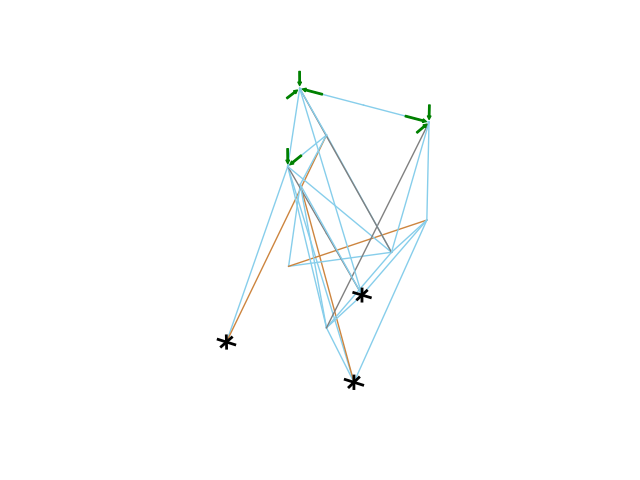

In [3]:
# Continue optimization where it left off if it was stopped in Cell 1 above.

# m.setParam("MIPFocus", 3) # Default: m.setParam("MIPFocus", 0)
m.optimize()

A_opt = A.X
a_opt = a.X
q_opt = q.X
u_opt = u.X
v_opt = v.X
z_opt = z.X
if prestress == True:
    q0_opt = q0.X
    qe_opt = qe.X
    z2_opt = z2.X

# ------------------------------------------ Plot Optimized Structure -------------------------------------------

# Isometric View
fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection = '3d') # , proj_type = 'ortho'
for i in range(N):
    for j in range(M):
        if z_opt[i,j] > 0:
            node1 = ien[i, 0].astype(int)
            node2 = ien[i, 1].astype(int)
            x0 = [nodes[node1, 0], nodes[node2, 0]]
            y0 = [nodes[node1, 1], nodes[node2, 1]]
            z0 = [nodes[node1, 2], nodes[node2, 2]]
            ax2.plot(x0, y0, z0, color = material_colors[j], linewidth = 1) #A_opt[i,j]/A_opt.max()
ax2.view_init(elev = 30, azim = -60)
ax2.axes.set_xlim3d(left = x_mid - dim/2, right = x_mid + dim/2) 
ax2.axes.set_ylim3d(bottom = y_mid - dim/2, top = y_mid + dim/2) 
ax2.axes.set_zlim3d(bottom = z_mid - dim/2, top = z_mid + dim/2)
ax2.axis('off')
            
# Plot Boundary and Loading Conditions
index = 0
for i in range(len(dof)):
    if index == 0:
        index = 1
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], \
                    [nodes.flatten()[i + 2], nodes.flatten()[i + 2]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i],
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    elif index == 1:
        index = 2
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i],
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    else:
        index = 0
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i - 2], nodes.flatten()[i - 2]], \
                    [nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                        color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i],
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

fig1.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)
fig2.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)

# Save Figures
fig1.savefig('Image_Ground_Structure.eps', format = 'eps')
fig1.savefig('Image_Ground_Structure.png', format = 'png', dpi = 1000)
fig2.savefig('Image_Design.eps', format = 'eps')
fig2.savefig('Image_Design.png', format = 'png', dpi = 1000)

# Save Variables
A_data = pd.DataFrame(A_opt)
A_data.to_csv('Data_A.csv')
a_data = pd.DataFrame(a_opt)
a_data.to_csv('Data_a2.csv')
q_data = pd.DataFrame(q_opt)
q_data.to_csv('Data_q.csv')
u_data = pd.DataFrame(u_opt)
u_data.to_csv('Data_u.csv')
v_data = pd.DataFrame(v_opt)
v_data.to_csv('Data_v_elong.csv')
z_data = pd.DataFrame(z_opt)
z_data.to_csv('Data_z.csv')
if prestress == True:
    q0_data = pd.DataFrame(q0_opt)
    q0_data.to_csv('Data_q0.csv')
    q0_t_min_data = pd.DataFrame([q0_t_min])
    q0_t_min_data.to_csv('Data_q0_t_min.csv')
    qe_data = pd.DataFrame(qe_opt)
    qe_data.to_csv('Data_qe.csv')
    z2_data = pd.DataFrame(z2_opt)
    z2_data.to_csv('Data_z2.csv')

a_max_data = pd.DataFrame(a_max)
a_max_data.to_csv('Data_a_max.csv')
a_min_data = pd.DataFrame(a_min)
a_min_data.to_csv('Data_a_min.csv')
B_data = pd.DataFrame(B.toarray())
B_data.to_csv('Data_B.csv')
C_data = pd.DataFrame(C)
C_data.to_csv('Data_C.csv')
dof_data = pd.DataFrame(dof)
dof_data.to_csv('Data_dof.csv')
E_data = pd.DataFrame(E)
E_data.to_csv('Data_E.csv')
F_data = pd.DataFrame(F)
F_data.to_csv('Data_F.csv')
ien_data = pd.DataFrame(ien)
ien_data.to_csv('Data_ien.csv')
l_data = pd.DataFrame(l)
l_data.to_csv('Data_l.csv')
load_colors_data = pd.DataFrame(load_colors)
load_colors_data.to_csv('Data_load_colors.csv')
mat_colors_data = pd.DataFrame(material_colors)
mat_colors_data.to_csv('Data_mat_colors.csv')
max_node_data = pd.DataFrame(max_node)
max_node_data.to_csv('Data_max_node.csv')
n_data = pd.DataFrame(n.toarray())
n_data.to_csv('Data_n.csv')
nodes_data = pd.DataFrame(nodes)
nodes_data.to_csv('Data_nodes.csv')
prestress_data = pd.DataFrame({'prestress': [prestress]})
prestress_data.to_csv('Data_prestress.csv')
sc_data = pd.DataFrame(sc)
sc_data.to_csv('Data_sc.csv')
st_data = pd.DataFrame(st)
st_data.to_csv('Data_st.csv')
tensegrity_data = pd.DataFrame({'tensegrity': [tensegrity]})
tensegrity_data.to_csv('Data_tensegrity.csv')
V_data = pd.DataFrame(V)
V_data.to_csv('Data_V.csv')
v_max_data = pd.DataFrame(v_max)
v_max_data.to_csv('Data_v_max.csv')
v_min_data = pd.DataFrame(v_min)
v_min_data.to_csv('Data_v_min.csv')
if tensegrity == True:
    J_data = pd.DataFrame(J.flatten())
    J_data.to_csv('Data_J.csv')
    V2_data = pd.DataFrame(V2)
    V2_data.to_csv('Data_V2.csv')
    Y_data = pd.DataFrame(Y.flatten())
    Y_data.to_csv('Data_Y.csv')

In [4]:
# Determine corrected varaible values if there was error in McCormick relaxation

m2 = gp.Model()

# Define Variables
q_cor = m2.addMVar(shape = (N,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'q_cor')
u_cor = m2.addMVar(shape = (N_F,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'u_cor')
v_cor = m2.addMVar(shape = (N,L_C), lb = -1*float('inf'), vtype = GRB.CONTINUOUS, name = 'v')

# Define Objective
m2.setObjective(sum(l[i]*A_opt[i,j]*C[j] for i in range(N) for j in range(M)), GRB.MINIMIZE)

# Define Constraints
m2.addConstrs((sum(B[k,i]*q_cor[i,h] for i in range(N)) == F[k,h] \
               for k in range(N_F) for h in range(L_C)), name = 'equilibrium')
m2.addConstrs((sum(Af[i,k]*u_cor[k,h] for k in range(N_F)) == v_cor[i,h] \
               for i in range(N) for h in range(L_C)), name = 'compatibility')
if prestress == False:
    m2.addConstrs((q_cor[i,h] == sum(E[j]*A_opt[i,j]/l[i] for j in range(M))*v_cor[i,h] \
                   for i in range(N) for h in range(L_C)), name = 'elongations')

elif prestress == True:
    m2.addConstrs((q_cor[i,h] == sum(E[j]*A_opt[i,j]/l[i] for j in range(M))*v_cor[i,h] + q0_opt[i] \
                   for i in range(N) for h in range(L_C)), name = 'elongations_prestress')

m2.optimize()

q_opt_cor = q_cor.X
u_opt_cor = u_cor.X
v_opt_cor = v_cor.X

# Save Variables
q_data_cor = pd.DataFrame(q_opt_cor)
q_data_cor.to_csv('Data_q_cor.csv')
u_data_cor = pd.DataFrame(u_opt_cor)
u_data_cor.to_csv('Data_u_cor.csv')
v_data_cor = pd.DataFrame(v_opt_cor)
v_data_cor.to_csv('Data_v_elong_cor.csv')

Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 25.1.0 25B78)

CPU model: Apple M3 Max
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 685 rows, 685 columns and 2983 nonzeros
Model fingerprint: 0x65aedde4
Coefficient statistics:
  Matrix range     [8e-02, 4e+05]
  Objective range  [0e+00, 0e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-04, 8e+01]
Presolve removed 674 rows and 674 columns
Presolve time: 0.00s
Presolved: 11 rows, 11 columns, 86 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      10    4.4668436e+02   0.000000e+00   0.000000e+00      0s

Solved in 10 iterations and 0.00 seconds (0.00 work units)
Optimal objective  4.466843605e+02


In [5]:
total_time = 255 + 57.4/60
total_time

255.95666666666668